# Overview
This notebook takes several steps to generate the final data file that will be used for further model development:

✅ **imports raw data files and adds columns:**
* glucose: level of glucose level obtained from both automatically scanned (historical glucose level) glucose levels and manually scanned ones (scan glucose level)
* glucose category: indicates what the glucose levels are grouped into
(level < 65: hypoglycemia / 65 ≤ level ≤ 250: normal / 250 < level: hyperglycemia)
* safe: indicates whether the levels are safe or not (1: safe / 0: unsafe)
* rate of change (roc): calculates the amount of change between a measurement at a time stamp and its subsequent measure

✅ **splits data into subsets**

👉 Noticing that the measures have big gaps in between due to changing the device and/or pausing and then resuming monitoring the canine glucose levels, we further divide the data into subsets where multiple groups of time-series data may belong to one canine.

✅ **calculating roc**

👉 For forecasting tasks, we only use subsets with observations greater than 10 to use previous 10 data points to predict the last 11th data point's glucose level. Rate-of-change is calculated within this subset in both units of minutes and seconds.

In [ ]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
!python --version

Python 3.12.12


In [ ]:
pd.set_option("display.max_rows", 100)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 🔆 Canine Data Load & Clean

In [ ]:
import os

dataset_path = '/content/drive/MyDrive/DATASCI210/210 Capstone/datasets'

if os.path.exists(dataset_path):
    print(f"Files in '{dataset_path}' starting with 'Talk':")
    found_files = [f for f in os.listdir(dataset_path) if f.startswith('Talk')]
    if found_files:
        for f in found_files:
            print(f)
    else:
        print("No files found starting with 'Talk'.")
else:
    print(f"Directory '{dataset_path}' not found. Please ensure Google Drive is mounted and the path is correct.")

Files in '/content/drive/MyDrive/DATASCI210/210 Capstone/datasets' starting with 'Talk':
TalkFile_현수김_glucose_canine6.csv
TalkFile_연주송_glucose_canine4.csv
TalkFile_지혜김_glucose_canine5.csv
TalkFile_버찌버찌_glucose_canine1.csv
TalkFile_빵진_glucose_canine2.csv
TalkFile_사랑이김_glucose_canine3.csv


### ID - Dog matching
* canine1: Buchi-Buchi
* canine2: Bbang-jin
* canine3: Sarang
* canine4: Yeonjoo Song
* canine5: Jihye Kim
* canine6: Hyeon-Soo Kim

In [ ]:
file1 = os.path.join(dataset_path, found_files[0])
file1_pd = pd.read_csv(file1)
file1_pd.head()

,Device,Serial Number,Device Timestamp,Record Type,Historic Glucose mg/dL,Scan Glucose mg/dL
0,FreeStyle LibreLink,1c495fbf-c5dd-4bfb-8185-a28bbaa3fe95,12/1/25 17:36,0,277.0,NaN
1,FreeStyle LibreLink,1c495fbf-c5dd-4bfb-8185-a28bbaa3fe95,12/1/25 17:51,0,283.0,NaN
2,FreeStyle LibreLink,1c495fbf-c5dd-4bfb-8185-a28bbaa3fe95,12/1/25 18:06,0,273.0,NaN
3,FreeStyle LibreLink,1c495fbf-c5dd-4bfb-8185-a28bbaa3fe95,12/1/25 18:22,0,268.0,NaN
4,FreeStyle LibreLink,1c495fbf-c5dd-4bfb-8185-a28bbaa3fe95,12/1/25 18:37,0,270.0,NaN


In [ ]:
dfs = []


for filename in found_files:
    full_file_path = os.path.join(dataset_path, filename)

    # Extract identifier to be 'canine1', 'canine2', etc.
    identifier = filename.split('_glucose_')[1].split('.')[0]

    # Read the file into a DataFrame
    df = pd.read_csv(full_file_path)

    # Add a new column 'ID' (changed name from file_identifier)
    df['ID'] = identifier


    # Append the processed DataFrame to the list
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

# sort by ID
combined_df = combined_df.sort_values(by = ["ID"])

print(f"Shape of the combined DataFrame: {combined_df.shape}")
# printing everything because we only have 6 rows
print("Combined DataFrame:")
display(combined_df.groupby("ID").first())


Shape of the combined DataFrame: (38760, 7)
Combined DataFrame:


,Device,Serial Number,Device Timestamp,Record Type,Historic Glucose mg/dL,Scan Glucose mg/dL
ID,,,,,,
canine1,FreeStyle LibreLink,90368fa5-f3e6-47f7-82bd-ced2486bb95b,12/2/25 2:45,0,480.0,103.0
canine2,FreeStyle LibreLink,62A42483-61C3-4AC9-A34E-059DA2BC3735,4/17/25 3:58,0,240.0,114.0
canine3,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,5/16/25 22:37,0,500.0,303.0
canine4,FreeStyle LibreLink,3689d896-77d3-4df0-9ac5-55b436d78db5,4/9/25 4:49,0,177.0,239.0
canine5,FreeStyle LibreLink,E9A0CE98-AA19-4E58-8F27-31A26580354B,3/27/25 12:52,1,405.0,412.0
canine6,FreeStyle LibreLink,e7ddfae7-5081-4ed3-a861-f47b50cc1bcb,10/15/25 9:25,0,389.0,298.0


### Record type
Comes from pdf printouts from FreeLibre
* 0: Historic glucose level (mg/dL)
  
  ➡ automatically measured glucose level by device

* 1: Scanned glucose level (mg/dL)

  ➡ manually scanned glucose level by user (pet owner)

* 6: Other things logged by the user (comments / exercise)

  ➡ normal to be blank

In [ ]:
glucose_counts = combined_df.groupby(["ID", "Record Type"])[['Historic Glucose mg/dL', 'Scan Glucose mg/dL']].count()
display(glucose_counts)

Historic Glucose mg/dL  Scan Glucose mg/dL
ID      Record Type                                            
canine1 0                              2424                   0
        1                                 0                 680
        6                                 0                   0
canine2 0                               919                   0
        1                                 0                  90
        6                                 0                   0
canine3 0                              3861                   0
        1                                 0                2112
        6                                 0                   0
canine4 0                              2235                   0
        1                                 0                 235
        6                                 0                   0
canine5 0                              4556                   0
        1                                 0                1507
        6                                 0                   0
canine6 0                              9775                   0
        1                                 0                4502
        5                                 0                   0
        6                                 0                   0

# 🔆 Adding Columns

## ⭐ Glucose Column
: We use both automatically measured glucose level by device every five minutes and manually scanned glucose level by the owner

Note: The five-minute interval restarts if the owner scans

(e.g., 0 -> 5 -> 10...(scans at 12) -> 17 -> 22 -> ...)

⭐ Additionally, we convert **timestamp into datetime object** here



---
## Canine df with combined glucose level measures and hypo/hyperglycemia columns

* also check dtypes


In [ ]:

# Keep only rows where Record Type is 0 or 1
canine_df = combined_df[combined_df['Record Type'].isin ([0,1])].copy()
canine_df['glucose'] = canine_df['Historic Glucose mg/dL'].fillna(canine_df['Scan Glucose mg/dL'])

# Format Columns and Create canine_df
canine_df = canine_df[['ID', 'Device Timestamp', 'glucose']]
canine_df = canine_df.rename(columns={'Device Timestamp': 'timestamp'})

canine_df['timestamp'] = pd.to_datetime(canine_df['timestamp'], format='%m/%d/%y %H:%M')
# canine_df['hypoglycemia']  = canine_df['glucose'] < 65
# canine_df['hyperglycemia'] = canine_df['glucose'] > 250


print(f"Shape of canine_df: {canine_df.shape}")
# print first 3 rows for each canine
display(canine_df.groupby("ID").head(3))
canine_df.dtypes

Shape of canine_df: (32896, 3)


,ID,timestamp,glucose
28437,canine1,2025-12-02 02:45:00,480.0
27786,canine1,2025-11-19 13:23:00,212.0
27787,canine1,2025-11-19 13:38:00,210.0
29695,canine2,2025-04-17 03:58:00,240.0
29694,canine2,2025-04-17 03:43:00,249.0
29702,canine2,2025-04-17 05:43:00,231.0
31408,canine3,2025-05-16 22:37:00,500.0
31407,canine3,2025-05-16 22:22:00,500.0
31383,canine3,2025-05-16 15:51:00,456.0
16469,canine4,2025-04-09 04:49:00,177.0


,0
ID,object
timestamp,datetime64[ns]
glucose,float64


## ⭐ Glucose_category & Normal Column

### Analyze Hypoglycemia and Hyperglycemia Events

* Quantify the frequency and duration of hypoglycemia (glucose < 65) and hyperglycemia (glucose > 250) events for each canine ID

* Adding in 'normal' column that indicates whether the state is safe or unsafe
  * glucose in normal range = True
  * hypo/hyperglycemic events = False

* We see the counts/percentages of events here as well


In [ ]:
def categorize_glucose(glucose):
    if glucose < 65:
        return 'Hypoglycemia'
    elif glucose > 250:
        return 'Hyperglycemia'
    else:
        return 'Normal'

canine_df['glucose_category'] = canine_df['glucose'].apply(categorize_glucose)
canine_df["normal_range"] = canine_df["glucose_category"] == "Normal"

print("First 10 rows with new 'glucose_category' column:")
display(canine_df.groupby("ID").first())

First 10 rows with new 'glucose_category' column:


,timestamp,glucose,glucose_category,normal_range
ID,,,,
canine1,2025-12-02 02:45:00,480.0,Hyperglycemia,False
canine2,2025-04-17 03:58:00,240.0,Normal,True
canine3,2025-05-16 22:37:00,500.0,Hyperglycemia,False
canine4,2025-04-09 04:49:00,177.0,Normal,True
canine5,2025-03-27 12:52:00,412.0,Hyperglycemia,False
canine6,2025-10-15 09:25:00,389.0,Hyperglycemia,False


In [ ]:
category_counts = canine_df.groupby(["ID", "glucose_category"]).size().unstack(fill_value=0)
category_counts['Total'] = category_counts.sum(axis=1)
print("Counts of glucose categories per canine ID:")
display(category_counts)

Counts of glucose categories per canine ID:


glucose_category,Hyperglycemia,Hypoglycemia,Normal,Total
ID,,,,
canine1,1957,117,1030,3104
canine2,338,36,635,1009
canine3,3586,27,2360,5973
canine4,394,0,2076,2470
canine5,4812,9,1242,6063
canine6,9754,158,4365,14277


In [ ]:
category_percentages = category_counts.iloc[:, :-1].div(category_counts['Total'], axis=0) * 100
category_percentages = category_percentages.round(2)

print("Percentages of glucose categories per file_identifier:")
display(category_percentages)

Percentages of glucose categories per file_identifier:


glucose_category,Hyperglycemia,Hypoglycemia,Normal
ID,,,
canine1,63.05,3.77,33.18
canine2,33.50,3.57,62.93
canine3,60.04,0.45,39.51
canine4,15.95,0.00,84.05
canine5,79.37,0.15,20.48
canine6,68.32,1.11,30.57


# 🔆 Splitting data into subsets

## ⭐ Distribution of glucose measurements: Before split

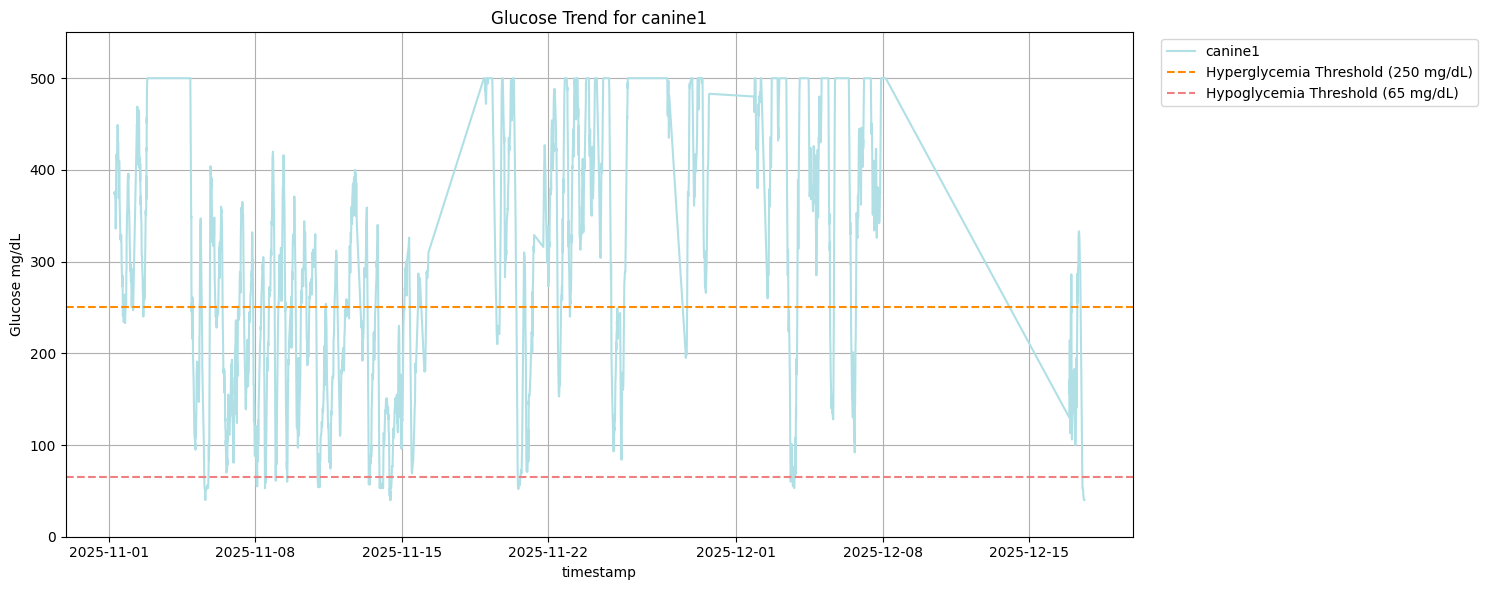

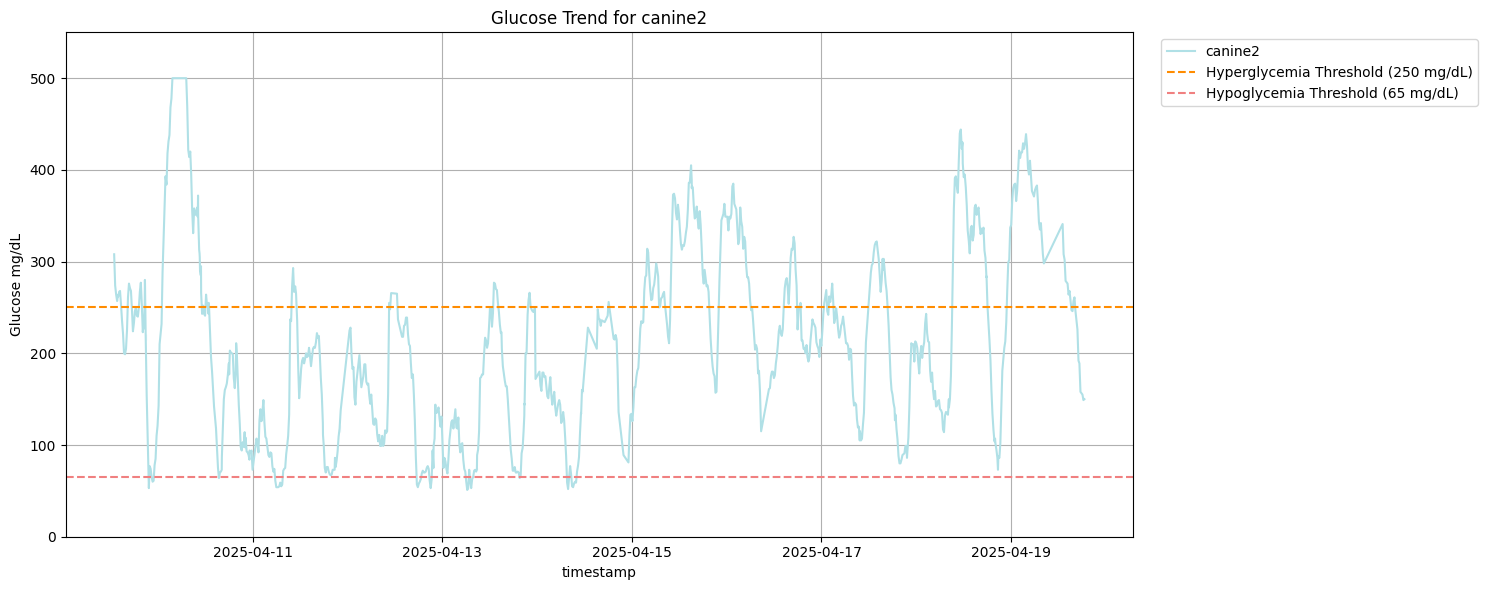

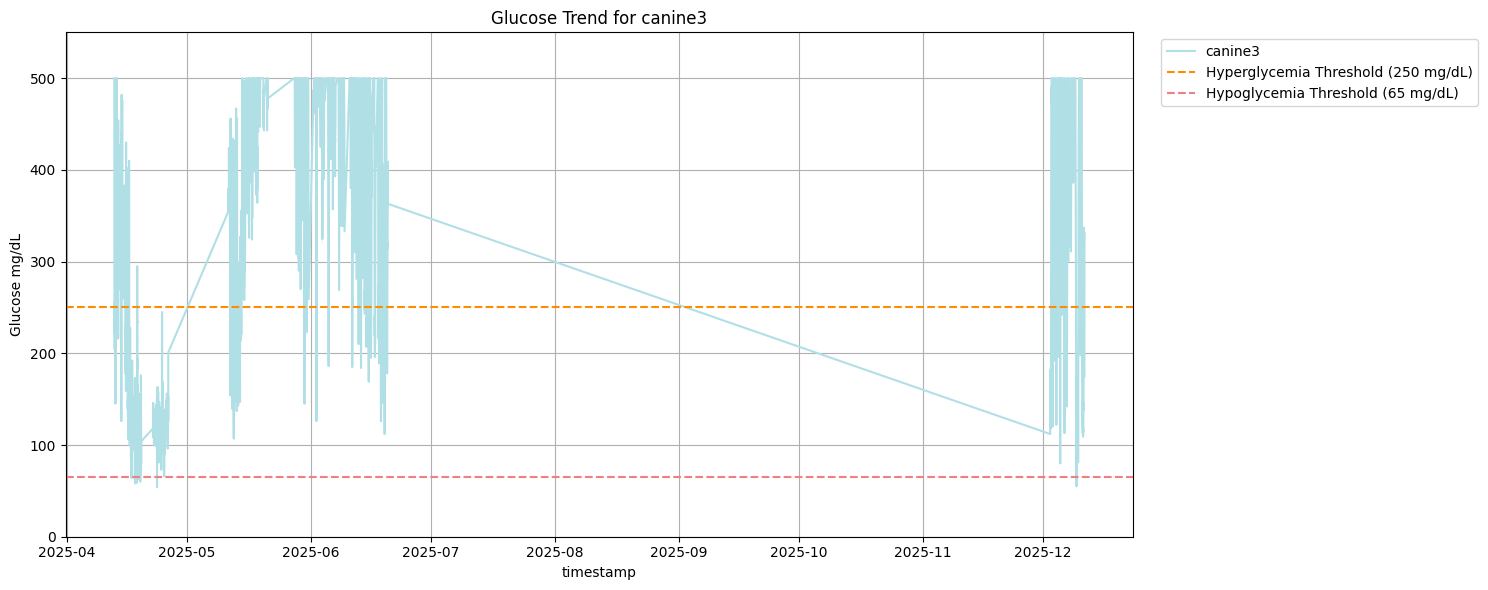

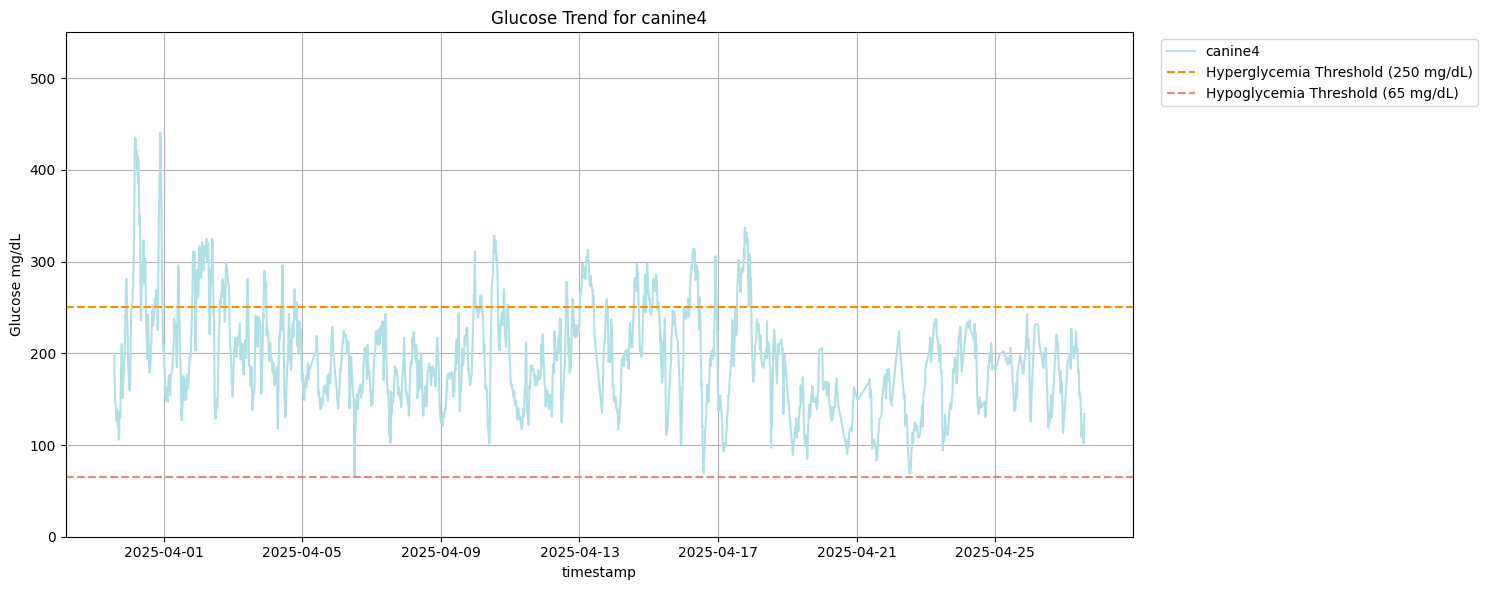

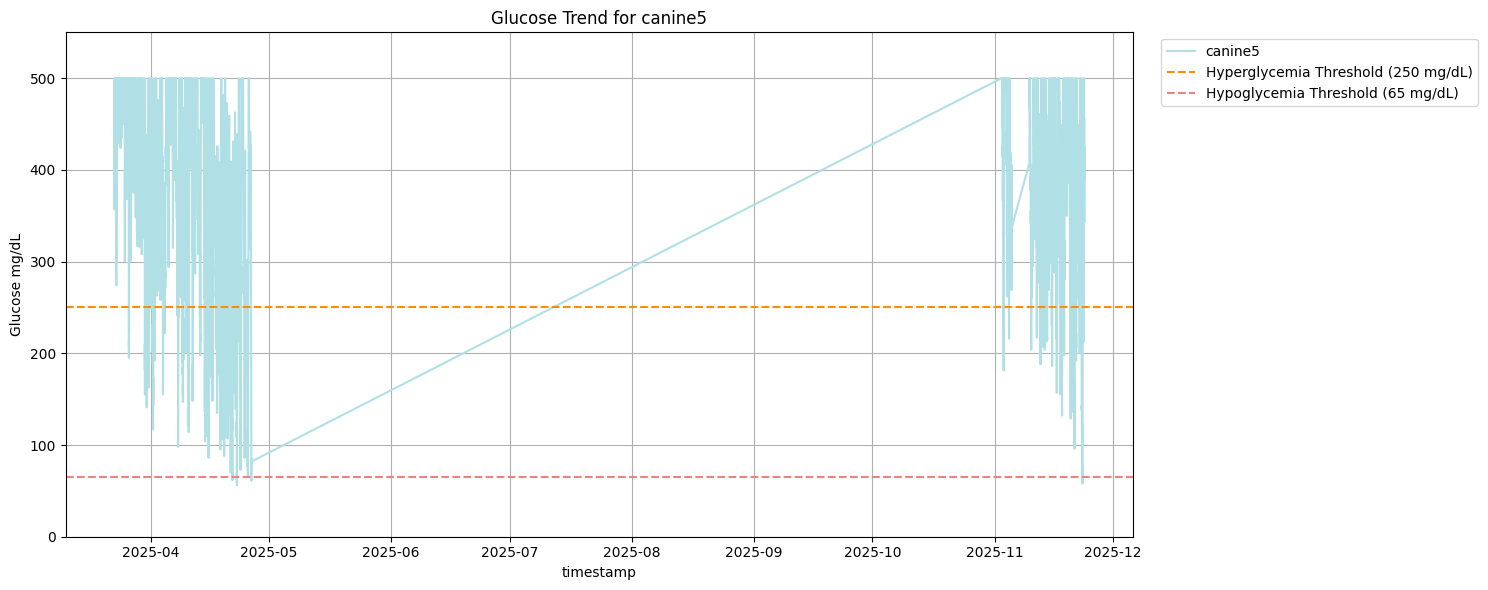

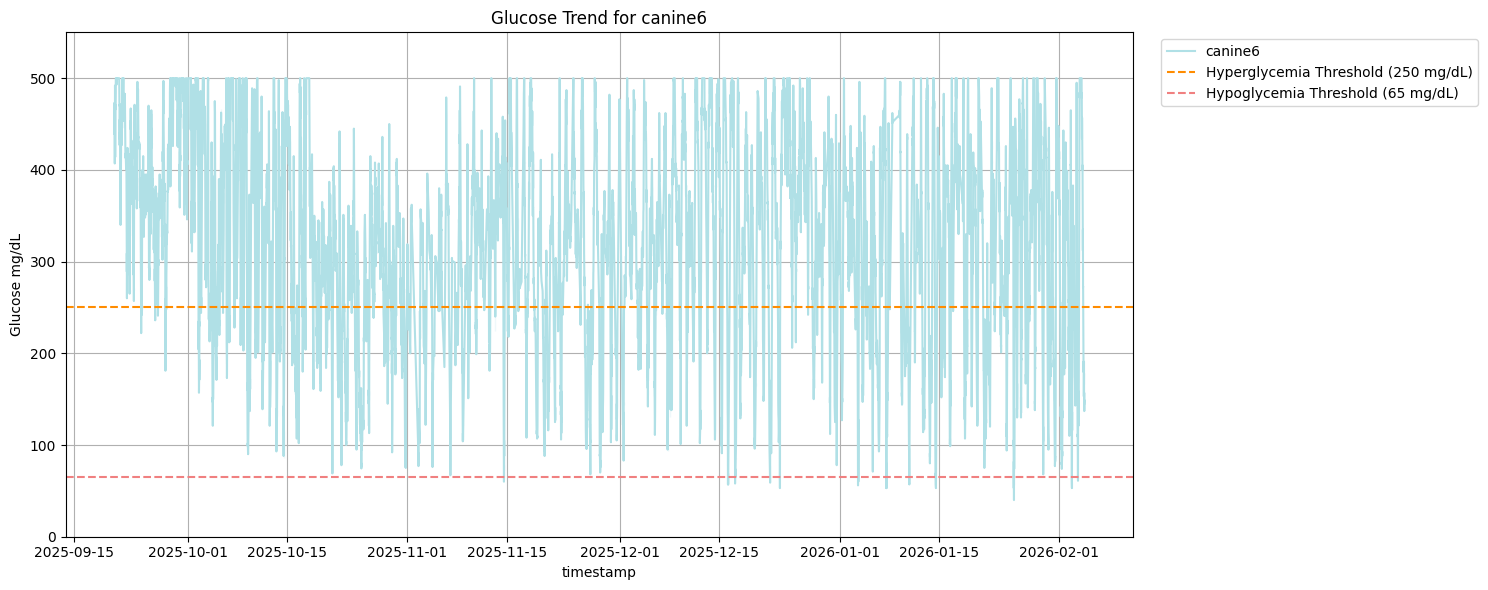

In [ ]:
# revised from Ci's code
unique_ids = canine_df['ID'].unique()

for id in unique_ids:
    plt.figure(figsize=(15, 6))

    # Filter data for the current id
    df_filtered = canine_df[canine_df['ID'] == id]

    # Sort by 'timestamp' to ensure chronological order
    df_filtered = df_filtered.sort_values(by='timestamp')

    # Plot glucose trend for the current identifier
    sns.lineplot(data=df_filtered, x='timestamp', y='glucose', label=id, color = "powderblue")

    # Add alarming thresholds for glucose = 250 (Hyperglycemia) first
    plt.axhline(y=250, color='darkorange', linestyle='--', label='Hyperglycemia Threshold (250 mg/dL)')
    # Add alarming thresholds for glucose = 65 (Hypoglycemia) second
    plt.axhline(y=65, color='lightcoral', linestyle='--', label='Hypoglycemia Threshold (65 mg/dL)')


    plt.title(f'Glucose Trend for {id}')
    plt.xlabel('timestamp')
    plt.ylabel('Glucose mg/dL')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='')
    plt.grid(True)
    plt.ylim((0, 550))
    plt.tight_layout()
    plt.show()

## ⭐ Splitting data (canine_filtered)
: We noticed that there are gaps (in terms of days) for each canine that comes from changing device / pause in measurement and then resuming

* Splitting the data will result in multiple datasets that come from one canine data
* The dataframe resulting from this process is 'canine_filtered'

#### Statistics for the gaps that are greater than one hour:
* Before setting the threshold for the gap that we will use for splitting the data, let's look at the statistics of the gaps that are in the data

In [ ]:
# sort the data just in case
gap_df = canine_df.sort_values(["ID", "timestamp"]).copy()
gap_df.groupby("ID").head(2)

,ID,timestamp,glucose,glucose_category,normal_range
27652,canine1,2025-11-01 05:51:00,375.0,Hyperglycemia,False
27653,canine1,2025-11-01 06:06:00,375.0,Hyperglycemia,False
28994,canine2,2025-04-09 12:56:00,308.0,Hyperglycemia,False
28995,canine2,2025-04-09 13:11:00,274.0,Hyperglycemia,False
30053,canine3,2025-04-12 19:03:00,500.0,Hyperglycemia,False
33914,canine3,2025-04-12 19:06:00,500.0,Hyperglycemia,False
15583,canine4,2025-03-30 13:38:00,200.0,Normal,True
15584,canine4,2025-03-30 13:53:00,177.0,Normal,True
22668,canine5,2025-03-22 17:43:00,478.0,Hyperglycemia,False
22669,canine5,2025-03-22 17:44:00,475.0,Hyperglycemia,False


🔹 get time intervals between measures

In [ ]:
gap_df["gap_min"] = (
    gap_df.groupby("ID")["timestamp"]
    .diff()
    .dt.total_seconds() / 60
)

gap_df["gap_hour"] = (
    gap_df["gap_min"]/60
)

The first row for each canine ID data has gap of NaN, which makes sense

In [ ]:
gap_df.groupby("ID").head(2)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,gap_hour
27652,canine1,2025-11-01 05:51:00,375.0,Hyperglycemia,False,NaN,NaN
27653,canine1,2025-11-01 06:06:00,375.0,Hyperglycemia,False,15.0,0.250000
28994,canine2,2025-04-09 12:56:00,308.0,Hyperglycemia,False,NaN,NaN
28995,canine2,2025-04-09 13:11:00,274.0,Hyperglycemia,False,15.0,0.250000
30053,canine3,2025-04-12 19:03:00,500.0,Hyperglycemia,False,NaN,NaN
33914,canine3,2025-04-12 19:06:00,500.0,Hyperglycemia,False,3.0,0.050000
15583,canine4,2025-03-30 13:38:00,200.0,Normal,True,NaN,NaN
15584,canine4,2025-03-30 13:53:00,177.0,Normal,True,15.0,0.250000
22668,canine5,2025-03-22 17:43:00,478.0,Hyperglycemia,False,NaN,NaN
22669,canine5,2025-03-22 17:44:00,475.0,Hyperglycemia,False,1.0,0.016667


In [ ]:
gap_df.groupby("ID")["gap_min"].agg(["min", "max", "median", "count", "std"])

,min,max,median,count,std
ID,,,,,
canine1,0.0,12641.0,15.0,3103,253.778454
canine2,0.0,285.0,15.0,1008,12.809398
canine3,0.0,238532.0,15.0,5972,3102.259836
canine4,0.0,483.0,15.0,2469,21.011516
canine5,0.0,273825.0,15.0,6062,3517.755277
canine6,0.0,1445.0,15.0,14276,30.168454


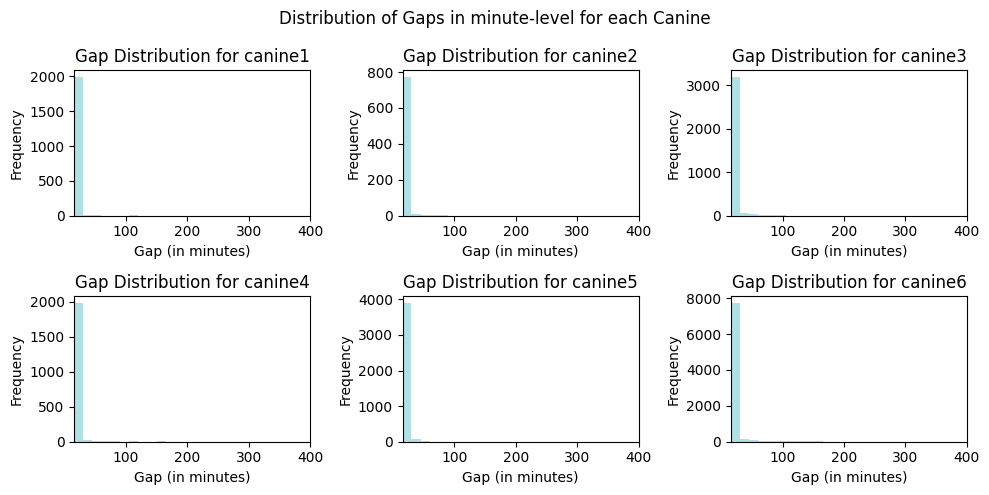

In [ ]:
import numpy as np

unique_ids = gap_df['ID'].unique()
n = len(unique_ids)

cols = 3
rows = 2

fig, axes = plt.subplots(rows, cols, figsize = (10, 5))
axes = axes.flatten()

for i, id in enumerate(unique_ids):

    df = gap_df[gap_df['ID'] == id]

    # Calculate bin edges to achieve a bin width of 5
    min_val = df["gap_min"].min()
    max_val = df["gap_min"].max()
    bins = np.arange(min_val, max_val + 15, 15)

    axes[i].hist(df["gap_min"], bins = bins, color = "powderblue")
    axes[i].set_xlabel("Gap (in minutes)")
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"Gap Distribution for {id}")
    axes[i].set_xlim(16, 400)
    # axes[i].set_ylim(0, 20)
    # axes[i].set_yticks(range(0, 80, 10))

plt.suptitle("Distribution of Gaps in minute-level for each Canine")
plt.tight_layout()
plt.show()

🔹 filter only gaps that are greater than **one-hour**

* gap_min: gap in minutes
* gap_hour: gap in hours
* gap_day: gap in days

In [ ]:
large_gaps = gap_df[gap_df["gap_min"] >= 60].copy()
large_gaps["gap_hour"] = large_gaps["gap_min"] / 60
large_gaps["gap_day"] = large_gaps["gap_hour"] / 24

In [ ]:
display(large_gaps[["gap_min", "gap_hour", "gap_day"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print(f"Minutes in one-day: {60*24}")

,gap_min,gap_hour,gap_day
count,444.000000,444.000000,444.000000
mean,1474.290541,24.571509,1.023813
std,17245.864065,287.431068,11.976294
min,60.000000,1.000000,0.041667
50%,120.000000,2.000000,0.083333
90%,377.400000,6.290000,0.262083
95%,626.100000,10.435000,0.434792
99%,8089.120000,134.818667,5.617444
max,273825.000000,4563.750000,190.156250


Minutes in one-day: 1440


#### Gap counts by canine ID

In [ ]:
print("Gap (in minutes)")
display(large_gaps.groupby("ID")["gap_min"].agg(["count", "mean", "median", "min", "max"]))

print("==="*20)
print("Gap (in hours)")
display(large_gaps.groupby("ID")["gap_hour"].agg(["count", "mean", "median", "min", "max"]))

print("==="*20)
print("Gap (in days)")
display(large_gaps.groupby("ID")["gap_day"].agg(["count", "mean", "median", "min", "max"]))


Gap (in minutes)


,count,mean,median,min,max
ID,,,,,
canine1,24,1239.833333,215.0,72.0,12641.0
canine2,12,104.083333,77.5,60.0,285.0
canine3,76,3813.618421,120.5,60.0,238532.0
canine4,43,141.418605,106.0,60.0,483.0
canine5,18,15772.388889,195.0,60.0,273825.0
canine6,271,161.479705,116.0,60.0,1445.0


Gap (in hours)


,count,mean,median,min,max
ID,,,,,
canine1,24,20.663889,3.583333,1.2,210.683333
canine2,12,1.734722,1.291667,1.0,4.750000
canine3,76,63.560307,2.008333,1.0,3975.533333
canine4,43,2.356977,1.766667,1.0,8.050000
canine5,18,262.873148,3.250000,1.0,4563.750000
canine6,271,2.691328,1.933333,1.0,24.083333


Gap (in days)


,count,mean,median,min,max
ID,,,,,
canine1,24,0.860995,0.149306,0.050000,8.778472
canine2,12,0.072280,0.053819,0.041667,0.197917
canine3,76,2.648346,0.083681,0.041667,165.647222
canine4,43,0.098207,0.073611,0.041667,0.335417
canine5,18,10.953048,0.135417,0.041667,190.156250
canine6,271,0.112139,0.080556,0.041667,1.003472


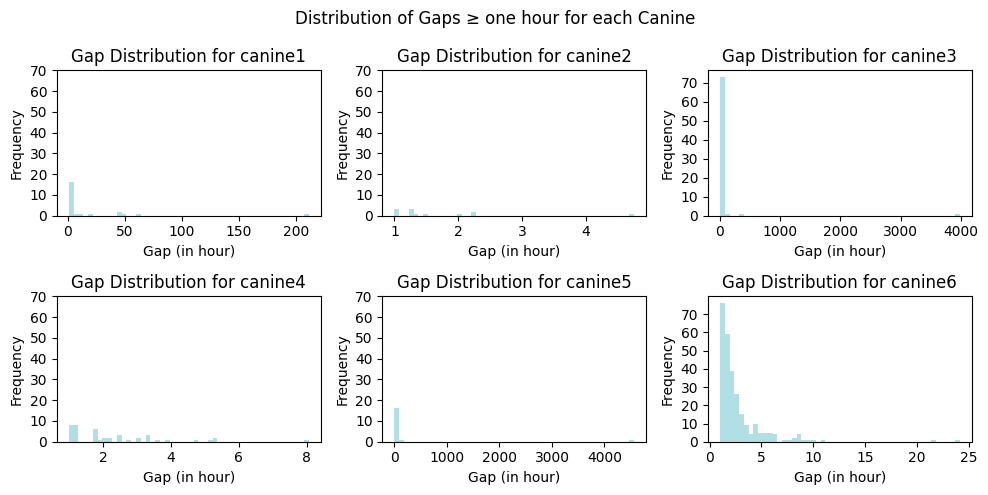

In [ ]:
unique_ids = large_gaps['ID'].unique()
n = len(unique_ids)

cols = 3
rows = 2

fig, axes = plt.subplots(rows, cols, figsize = (10, 5))
axes = axes.flatten()

for i, id in enumerate(unique_ids):

    df = large_gaps[large_gaps['ID'] == id]

    axes[i].hist(df["gap_hour"], bins = 50, color = "powderblue")
    axes[i].set_xlabel("Gap (in hour)")
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"Gap Distribution for {id}")
    # axes[i].set_ylim(0, 20)
    axes[i].set_yticks(range(0, 80, 10))

plt.suptitle("Distribution of Gaps ≥ one hour for each Canine")
plt.tight_layout()
plt.show()

#### Checking proportion of the gaps
* Proportion of gaps larger than or equal to 1 hour: 1.35% of all gaps
* .06% of the gaps between 30-60 minutes

In [ ]:
gap_df.groupby("ID")["gap_hour"].describe()
print((gap_df["gap_hour"]>=1).mean())
((gap_df["gap_hour"] > .5) & (df["gap_hour"] <= 1)).mean()

0.013497081712062257


np.float64(0.000638375486381323)

#### ❗Threshold as 60 minutes

In [ ]:
max_gap_minutes = 60

In [ ]:
# define a function for splitting(segmenting)

def data_split(df, max_gap_minutes = max_gap_minutes):
  df = df.copy()

  df = df.sort_values(["ID", "timestamp"])

  # compute time difference in minutes
  df["gap_min"] = (
      df.groupby("ID")["timestamp"]
      .diff()
      .dt.total_seconds() / 60
  )

  # flagging gaps where the data should be split
  df["split_flag"] = (
      (df["gap_min"] >= max_gap_minutes) |
      (df["gap_min"].isna())
  )

  # assigning new ids
  df["sub_id"] = (
      df.groupby("ID")["split_flag"]
      .cumsum()
  )
  df["sub_id"] = pd.to_numeric(df["sub_id"])


  separator = "-"
  df["split_id"] = (
      df["ID"] + separator + df["sub_id"].astype(str)
  )

  return df


In [ ]:
canine_split = data_split(canine_df, max_gap_minutes = max_gap_minutes)
print(f"Number of Groups: {canine_split['split_id'].nunique()}")
print("Number of Rows per dataset")

split_counts = canine_split.groupby("split_id", sort = False)["timestamp"].agg("count")
split_counts.describe()

Number of Groups: 450
Number of Rows per dataset


,timestamp
count,450.000000
mean,73.102222
std,132.728379
min,1.000000
25%,6.000000
50%,31.500000
75%,81.000000
max,1084.000000


### histograms of the gaps

In [ ]:
# placeholder for histogram

#### Removing Subsets with less than 10 observations

In [ ]:
min_observations = 11

In [ ]:
segment_counts = (
    canine_split
    .groupby("split_id", sort = False)["timestamp"]
    .agg("count")
)
segment_counts.head(3)

,timestamp
split_id,
canine1-1,96
canine1-2,142
canine1-3,480


After filtering, we are going to loose approximately 33% of the subgroups

In [ ]:
(segment_counts < 11).mean()

np.float64(0.3333333333333333)

In [ ]:
valid_segments = segment_counts[segment_counts > 10].index
valid_segments

Index(['canine1-1', 'canine1-2', 'canine1-3', 'canine1-4', 'canine1-5',
       'canine1-6', 'canine1-7', 'canine1-8', 'canine1-10', 'canine1-11',
       ...
       'canine6-262', 'canine6-263', 'canine6-265', 'canine6-266',
       'canine6-267', 'canine6-268', 'canine6-269', 'canine6-270',
       'canine6-271', 'canine6-272'],
      dtype='object', name='split_id', length=300)

In [ ]:
canine_filtered = canine_split[
    canine_split["split_id"].isin(valid_segments)
]

In [ ]:
print(canine_filtered.shape)
display(canine_filtered.groupby("split_id", sort = False)["timestamp"].agg("count").head(3))

(32320, 9)


,timestamp
split_id,
canine1-1,96
canine1-2,142
canine1-3,480


In [ ]:
print(f"Difference in rows between raw and filtered df: {len(canine_df) - len(canine_filtered)}")

print("--"*50)
print("Final filtered df statistics (number of observations)")
display(canine_filtered.groupby("split_id", sort = False)["timestamp"].count().describe())

Difference in rows between raw and filtered df: 576
----------------------------------------------------------------------------------------------------
Final filtered df statistics (number of observations)


,timestamp
count,300.000000
mean,107.733333
std,151.131703
min,11.000000
25%,31.750000
50%,59.000000
75%,110.250000
max,1084.000000


In [ ]:
# making the above process as function for subsequent cleaning
# var can be split_id or ID

def remove_short_segments(df, var, min_observations = min_observations):

  counts = (
      df.groupby(var)["timestamp"]
      .agg("count")
  )

  print(f"Number of Subgroups that are going to be removed: {(counts < min_observations).sum()}")
  print(f"Proportion of Subgroups that are going to be removed: {(counts < min_observations).mean()}")

  valid_segments = counts[counts > min_observations].index

  d = df[df[var].isin(valid_segments)]

  return d

### ✨ **Final Split Dataframe** (canine_split)


In [ ]:
# cleaning and finalizing the split_id and chaning this into final ID

def clean_finalize(df):
  final_df = df.copy()


  # create new seq segment numbers per base_id
  if "split_id" in final_df.columns:
    final_df["ID"] = final_df["ID"] + "-" + final_df["sub_id"].astype(str).str.zfill(3)

  else:
    final_df["base_id"] = final_df["ID"].str.split("-", n = 1).str[0]

    new_seg_numbers = (
      final_df[["base_id", "ID"]]
      .drop_duplicates()
      .assign(
          new_sub_id = lambda x: x.groupby("base_id").cumcount() + 1
      )
    )

  # merge back to the df
    final_df = final_df.merge(
      new_seg_numbers,
      on = ["base_id", "ID"],
      how = "left"
    )

  # rebuilding ID
    final_df["ID"] = final_df["base_id"] + "-" + final_df["new_sub_id"].astype(str).str.zfill(3)


  if "split_id" in final_df.columns:
    cols_to_drop = ["split_id", "sub_id"]
  else:
    cols_to_drop = ["base_id", "new_sub_id"]

  final_df = final_df.drop(columns = cols_to_drop)

  return final_df


In [ ]:
canine_filtered.head()

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,sub_id,split_id
27652,canine1,2025-11-01 05:51:00,375.0,Hyperglycemia,False,NaN,True,1,canine1-1
27653,canine1,2025-11-01 06:06:00,375.0,Hyperglycemia,False,15.0,False,1,canine1-1
27654,canine1,2025-11-01 06:21:00,373.0,Hyperglycemia,False,15.0,False,1,canine1-1
27655,canine1,2025-11-01 06:36:00,375.0,Hyperglycemia,False,15.0,False,1,canine1-1
27656,canine1,2025-11-01 06:51:00,376.0,Hyperglycemia,False,15.0,False,1,canine1-1


In [ ]:
canine_split = clean_finalize(canine_filtered)

In [ ]:
print(f"Number of final subgroups: {canine_split["ID"].nunique()}")
print(f"Number of final observations: {canine_split.shape[0]}")
print("Statistics for Observations (Number of Rows)")
display(canine_split.groupby("ID")["timestamp"].count().describe())

Number of final subgroups: 300
Number of final observations: 32320
Statistics for Observations (Number of Rows)


,timestamp
count,300.000000
mean,107.733333
std,151.131703
min,11.000000
25%,31.750000
50%,59.000000
75%,110.250000
max,1084.000000


In [ ]:
canine_split.groupby("ID").head(2).head(4)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag
27652,canine1-001,2025-11-01 05:51:00,375.0,Hyperglycemia,False,NaN,True
27653,canine1-001,2025-11-01 06:06:00,375.0,Hyperglycemia,False,15.0,False
26180,canine1-002,2025-11-02 07:54:00,450.0,Hyperglycemia,False,233.0,True
27220,canine1-002,2025-11-02 08:08:00,447.0,Hyperglycemia,False,14.0,False


# 🔆 Adding Rate Of Change

## ROC Definition

ROC (Rate of Change of glucose):
In CGM time series, ROC answers one question: **How fast is glucose changing right now?**


**Mathematical definition:** For two consecutive readings,






$$ROC_t = \frac{G_t - G_{t-1}}{\Delta t_{\text{minutes}}}$$




*   𝐺𝑡: glucose at time 𝑡 (mg/dL)
*   Δ𝑡: time gap between readings (in minutes)

*   Units: mg/dL per minute


**Interpretation:**


*   ROC < 0 → glucose is dropping
*   ROC > 0 → glucose is rising


*   Large |ROC| → fast change (dangerous for hypoglycemia)

In [ ]:
# revised from Ci's code

def add_dt(df):
  d = df.copy()

  # getting glucose difference for each ID (e.g., for canine1-001)
  d["glucose_diff"] = (
      d.groupby("ID")["glucose"]
      .diff()
  )

  # compute dt per minute
  d["dt_per_min"] = (
      d["glucose_diff"]/d["gap_min"]
  )

  return d

## ⭐ Removing Measures with the Same Timestamp (canine_final)
* From below, we can see that there are a total of 993 measures with time difference (in minutes) of 0.
* Among these duplicates, hypoglycemic events take 23 cases, thus the filtering process will prioritize lower glucose levels

💡 The final data now has 283 groups with 31,371 observations

In [ ]:
# print shape before dropping duplicates
print(f"Shape of canine_df before dropping duplicates: {canine_split.shape}")

Shape of canine_df before dropping duplicates: (32320, 7)


In [ ]:
canine_final = add_dt(canine_split)

display(canine_final[canine_final["gap_min"] == 0].head())
print(f"Number of duplicated timestamps: {canine_final[canine_final["gap_min"] == 0].shape[0]}")

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,glucose_diff,dt_per_min
28443,canine1-001,2025-11-01 13:52:00,330.0,Hyperglycemia,False,0.0,False,2.0,inf
27228,canine1-002,2025-11-02 09:19:00,438.0,Hyperglycemia,False,0.0,False,-1.0,-inf
26188,canine1-002,2025-11-02 09:55:00,427.0,Hyperglycemia,False,0.0,False,23.0,inf
27233,canine1-002,2025-11-02 09:57:00,411.0,Hyperglycemia,False,0.0,False,6.0,inf
26192,canine1-002,2025-11-02 10:56:00,416.0,Hyperglycemia,False,0.0,False,10.0,inf


Number of duplicated timestamps: 993


### How many duplicated measures are there per glucose_category?

✨ reminder to bring this part up during class discussion

In [ ]:
duplicate_counts = (
    canine_final
    .groupby("glucose_category")["gap_min"]
    .apply(lambda x: (x == 0).sum())
)

display(duplicate_counts)


duplicate_counts_glucose_diff = (
    canine_final[canine_final["gap_min"] == 0]
    .groupby("glucose_category")["glucose_diff"]
    .describe()
)

display(duplicate_counts_glucose_diff)

,gap_min
glucose_category,
Hyperglycemia,570
Hypoglycemia,19
Normal,404


,count,mean,std,min,25%,50%,75%,max
glucose_category,,,,,,,,
Hyperglycemia,570.0,0.543860,11.262283,-88.0,-1.0,0.0,1.0,58.0
Hypoglycemia,19.0,-0.631579,6.448174,-18.0,0.0,0.0,0.0,13.0
Normal,404.0,-0.834158,10.478607,-73.0,-3.0,0.0,2.0,35.0


#### Recomputing ROC for final data

In [ ]:
canine_final.head(2)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,glucose_diff,dt_per_min
0,canine1-001,2025-11-01 05:51:00,375.0,Hyperglycemia,False,NaN,True,NaN,NaN
1,canine1-001,2025-11-01 06:06:00,375.0,Hyperglycemia,False,15.0,False,0.0,0.0


In [ ]:
canine_final = (
    canine_final
    # sort such that lower glucose level comes first
    .sort_values(["ID", "timestamp", "glucose"])
    .drop_duplicates(subset = ["ID", "timestamp"], keep = "first")
    .reset_index(drop = True)
)

# recompute time difference and roc
canine_final = add_dt(canine_final)

In [ ]:
print(f"Number of duplicated timestamps - minutes: {canine_final[canine_final["gap_min"] == 0].shape[0]}")

Number of duplicated timestamps - minutes: 292


####❗Re-filtering subgroups with less than 11 observations

After removing duplicates, we see some subgroups with 10 observations. Let's clean this out again and reassign the IDs

In [ ]:
canine_final.groupby("ID")["split_flag"].count()

,split_flag
ID,
canine1-001,95
canine1-002,131
canine1-003,476
canine1-004,59
canine1-005,216
...,...
canine6-268,17
canine6-269,38
canine6-270,84


In [ ]:
canine_final.groupby("ID")["timestamp"].count().describe()

,timestamp
count,300.000000
mean,104.423333
std,143.704049
min,10.000000
25%,31.000000
50%,57.500000
75%,108.000000
max,945.000000


In [ ]:
canine_final = remove_short_segments(canine_final, "ID")

Number of Subgroups that are going to be removed: 2
Proportion of Subgroups that are going to be removed: 0.006666666666666667


In [ ]:
canine_final = clean_finalize(canine_final)

In [ ]:
canine_final.shape

(31252, 9)

In [ ]:
canine_final.groupby("ID")["timestamp"].count()

,timestamp
ID,
canine1-001,95
canine1-002,131
canine1-003,476
canine1-004,59
canine1-005,216
...,...
canine6-172,17
canine6-173,38
canine6-174,84


In [ ]:
canine_final["gap_min"].mean()

np.float64(31.671477949177493)

In [ ]:
canine_final[canine_final["split_flag"] == False]["gap_min"].describe()

,gap_min
count,30960.000000
mean,11.607655
std,6.522159
min,0.000000
25%,6.000000
50%,15.000000
75%,15.000000
max,58.000000


In [ ]:
canine_final.groupby("ID").head()

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,glucose_diff,dt_per_min
0,canine1-001,2025-11-01 05:51:00,375.0,Hyperglycemia,False,NaN,True,NaN,NaN
1,canine1-001,2025-11-01 06:06:00,375.0,Hyperglycemia,False,15.0,False,0.0,0.000000
2,canine1-001,2025-11-01 06:21:00,373.0,Hyperglycemia,False,15.0,False,-2.0,-0.133333
3,canine1-001,2025-11-01 06:36:00,375.0,Hyperglycemia,False,15.0,False,2.0,0.133333
4,canine1-001,2025-11-01 06:51:00,376.0,Hyperglycemia,False,15.0,False,1.0,0.066667
...,...,...,...,...,...,...,...,...,...
30987,canine6-176,2026-02-02 16:40:00,279.0,Hyperglycemia,False,105.0,True,NaN,NaN
30988,canine6-176,2026-02-02 16:55:00,244.0,Normal,True,15.0,False,-35.0,-2.333333
30989,canine6-176,2026-02-02 17:09:00,216.0,Normal,True,14.0,False,-28.0,-2.000000
30990,canine6-176,2026-02-02 17:10:00,216.0,Normal,True,1.0,False,0.0,0.000000


In [ ]:
# ROC Summary

def roc_quick_summary(d, name):
    print(f"\n=== {name} ===")
    print("dt_min (minutes) summary:")
    print(d["time_diff_min"].dropna().describe(percentiles=[.01, .05, .5, .95, .99]))

    roc = d["roc_per_min"].dropna()
    print("\nroc (mg/dL/min) summary:")
    print(roc.describe(percentiles=[.01, .05, .5, .95, .99]))

    print("\n% dt_min <= 0 (duplicates/out-of-order):",
          (d["time_diff_min"] <= 0).mean() * 100)

roc_quick_summary(canine_final, "CANINE")



=== CANINE ===
dt_min (minutes) summary:
count    31088.000000
mean        11.725232
std          6.675935
min          1.000000
1%           1.000000
5%           1.000000
50%         15.000000
95%         16.000000
99%         30.000000
max         60.000000
Name: time_diff_min, dtype: float64

roc (mg/dL/min) summary:
count    31088.000000
mean         0.044901
std          3.182583
min        -74.000000
1%          -8.000000
5%          -3.250000
50%          0.000000
95%          3.500000
99%          9.677500
max         84.000000
Name: roc_per_min, dtype: float64

% dt_min <= 0 (duplicates/out-of-order): 0.0


In [ ]:
# Export final data into csv
# target directory
out_dir = "/content/drive/MyDrive/DATASCI210/210 Capstone/WooJung/datasets"

# export dataframes
canine_final.to_csv(os.path.join(out_dir, "canine_final.csv"), index = False)

print("Files exported to:", out_dir)


Files exported to: /content/drive/MyDrive/DATASCI210/210 Capstone/WooJung/datasets


In [ ]:
# Export final data into pkl

out_dir = "/content/drive/MyDrive/DATASCI210/210 Capstone/WooJung/datasets"
os.makedirs(out_dir, exist_ok=True)

canine_final.to_pickle(os.path.join(out_dir, "canine_final.pkl"))

print("PKL file saved to:", out_dir)


PKL file saved to: /content/drive/MyDrive/DATASCI210/210 Capstone/WooJung/datasets
